# Task XII Evaluation: PQC Parameter Learning with PPO

## 1. Conceptual Overview: Quantum Parameter Learning as an RL Problem
In Task XI, we relied on a standard PyTorch MLP in a supervised setting to predict PQC parameters. For Task XII, we reinterpret the same challenge as a **Markov Decision Process (MDP)** and solve it using **Reinforcement Learning**.

---

## 2. Reinforcement Learning Setup

**Environment (Gymnasium):**  
A custom Gym environment hosts both our **target classical data** and the **quantum circuit**, serving as the playground for the RL agent.

**State (`s`):**  
The agent observes a vector of normally distributed data, scaled to a fixed range. This is the input representation the agent sees at every step.

**Action (`a`):**  
The agent outputs a set of continuous rotational angles, which are applied to the quantum circuit as parameterized rotations.

**Reward (`r`):**  
Since the ultimate goal is to minimize **Mean Squared Error (MSE)** between the quantum output and the target vector, we define the reward as **negative MSE**. Maximizing this reward inherently drives the agent to reduce the reconstruction error.

---

## 3. PPO Agent Structure

The **Proximal Policy Optimization (PPO)** agent uses an **actor network** to determine the actions. Through repeated interactions with the environment, the agent gradually improves its policy, effectively learning to produce **quantum rotation parameters** that replicate the mapping previously learned by the supervised MLP in Task XI.

By the end of training, the RL agent can **directly map normal-distributed input vectors to quantum states** with minimal error, achieving efficient PQC parameter estimation through reinforcement learning.

**Setup and Imports**

In [ ]:

%%capture
# 1. Installation and Library Setup
!pip install pennylane stable-baselines3 gymnasium -q

import pennylane as qml
from pennylane import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import warnings

# Mute all deprecation and system warnings for a clean PDF export
warnings.filterwarnings("ignore")

## 2. Custom Gym Environment for PQC

To interface with standard RL agents, we define a **Gym environment** wrapping our PennyLane circuit.

- **Observation Space:** A 4-dimensional Box with values in [−1, 1], representing the target vector.  
- **Action Space:** A 4-dimensional Box for continuous rotation angles, roughly spanning [−π, π].  
- **Step Mechanics:** The agent’s actions are applied as `Ry(θ)` rotations via `qml.AngleEmbedding`. The circuit outputs Pauli-Z expectations, the MSE with the target is computed, and its negative serves as the RL reward.

In [15]:
NUM_QUBITS = 4

quantum_device = qml.device("default.qubit", wires=NUM_QUBITS)


@qml.qnode(quantum_device, interface="numpy")
def pqc_forward(theta):
    """
    Parameterized quantum circuit that converts action parameters
    into expectation values.
    """

    # encode parameters as rotations
    qml.AngleEmbedding(theta, wires=range(NUM_QUBITS), rotation="Y")

    # measurement layer
    return [qml.expval(qml.PauliZ(w)) for w in range(NUM_QUBITS)]



# RL Environment

class QuantumStateEnv(gym.Env):

    def __init__(self, horizon=50):
        super().__init__()

        self.horizon = horizon
        self.timestep = 0

        # agent outputs PQC parameters
        self.action_space = spaces.Box(
            low=-1.0,
            high=1.0,
            shape=(NUM_QUBITS,),
            dtype=np.float32
        )

        # target vector sampled from normal distribution
        self.observation_space = spaces.Box(
            low=-1.0,
            high=1.0,
            shape=(NUM_QUBITS,),
            dtype=np.float32
        )

        self.target_state = None



    # Generate target data


    def _sample_target(self):

        noise = np.random.normal(0.0, 1.0, size=NUM_QUBITS)

        # keep inside observation bounds
        scaled = np.clip(noise / 2.5, -1.0, 1.0)

        return scaled.astype(np.float32)


    # Reset episode


    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.timestep = 0
        self.target_state = self._sample_target()

        return self.target_state, {}


    # Environment step

    def step(self, action):

        # convert normalized action into rotation angles
        rotation_angles = (action + 1.0) * (np.pi / 2.0)

        # run quantum circuit
        circuit_output = np.array(pqc_forward(rotation_angles))

        # compute MSE
        error = np.mean((circuit_output - self.target_state) ** 2)

        # RL reward (maximize negative error)
        reward = -10.0 * float(error)

        # update time
        self.timestep += 1
        done = self.timestep >= self.horizon

        info = {
            "target": self.target_state.copy(),
            "prediction": circuit_output,
            "mse": error
        }

        # next target state
        self.target_state = self._sample_target()

        return self.target_state, reward, done, False, info


print("Quantum RL Environment Ready.")

Quantum RL Environment Ready.


## 3. Testing a Random Action

Before training the PPO agent, we can simulate an **untrained policy** by feeding a **random set of angles** into the environment.  
This lets us **verify the environment mechanics** and observe the initially high MSE (low reward) before any learning occurs.

In [16]:
# 3. Test Run with an Untrained Agent

# create environment instance
environment = QuantumStateEnv()

# start a fresh episode
state, _ = environment.reset()

# generate a random action (no learning yet)
action_sample = environment.action_space.sample()

# interact with the environment
new_state, reward_value, done, truncated, details = environment.step(action_sample)


print("Random Policy Test (No Training Yet)")
print("-------------------------------------")
print("Target Vector:        ", np.round(state, 3))
print("Sampled Action:       ", np.round(action_sample, 3))
print("Quantum Output:       ", np.round(details["prediction"], 3))
print("Reward (−MSE scaled): ", np.round(reward_value, 4))
print("Mean Squared Error:   ", np.round(details["mse"], 4))

Random Policy Test (No Training Yet)
-------------------------------------
Target Vector:         [-0.29  -0.354 -0.328 -0.215]
Sampled Action:        [ 0.557  0.822 -0.116 -0.456]
Quantum Output:        [-0.767 -0.961  0.181  0.657]
Reward (−MSE scaled):  -4.0359
Mean Squared Error:    0.4036


## 4. Training with PPO

We use **Proximal Policy Optimization (PPO)**, an Actor-Critic method that constrains policy updates using a clipping mechanism. This helps the agent **learn safely and steadily** to map input values to rotation angles.

Using `stable_baselines3`, an **MlpPolicy** is automatically created. Functionally similar to Task XI’s MLP, it is now updated via **advantage-based reinforcement learning** instead of supervised gradient descent.

**Reinforcement Learning Phase**

In [23]:
# 4. Reinforcement Learning Optimization Phase

import warnings
warnings.filterwarnings("ignore")


class ErrorTracker(BaseCallback):

    def __init__(self, verbose=0, log_interval=5000):
        super().__init__(verbose)
        self.error_log = []
        self.log_interval = log_interval

    def _on_step(self) -> bool:

        info = self.locals["infos"][0]
        self.error_log.append(info["mse"])


        if self.num_timesteps % self.log_interval == 0:
            mse_val = info["mse"]
            reward_val = self.locals["rewards"][0]

            print(
              f"Step {self.num_timesteps} | "
              f"MSE: {mse_val:.4f} | "
              f"Reward: {reward_val:.4f}")

        return True


# create training environment
training_env = QuantumStateEnv(horizon=100)

# callback
tracker = ErrorTracker(log_interval=5000)

# PPO agent
agent = PPO(
    policy="MlpPolicy",
    env=training_env,
    learning_rate=1e-3,
    ent_coef=0.05,
    verbose=0,
    seed=42
)

print("Starting PPO training...\n")

agent.learn(
    total_timesteps=50000,
    callback=tracker
)

print("\nTraining finished.")

Starting PPO training...

Step 5000 | MSE: 0.4558 | Reward: -4.5582
Step 10000 | MSE: 0.3762 | Reward: -3.7621
Step 15000 | MSE: 0.7005 | Reward: -7.0051
Step 20000 | MSE: 0.3724 | Reward: -3.7238
Step 25000 | MSE: 0.8842 | Reward: -8.8423
Step 30000 | MSE: 0.3210 | Reward: -3.2104
Step 35000 | MSE: 0.6545 | Reward: -6.5448
Step 40000 | MSE: 0.6172 | Reward: -6.1723
Step 45000 | MSE: 0.2927 | Reward: -2.9272
Step 50000 | MSE: 0.5598 | Reward: -5.5978

Training finished.


**Visulaizing Results**

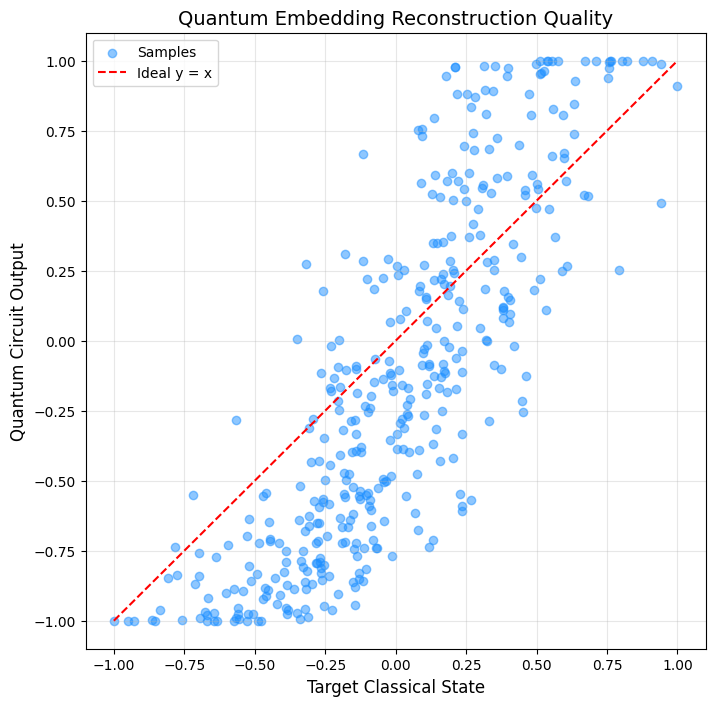

In [25]:
import matplotlib.pyplot as plt
import torch
import numpy as np


def visualize_reconstruction(policy_model, environment, samples=100):


    true_vals = []
    recon_vals = []

    for _ in range(samples):

        obs, _ = environment.reset()


        chosen_action, _ = policy_model.predict(obs, deterministic=True)


        if isinstance(chosen_action, torch.Tensor):
            chosen_action = chosen_action.cpu().numpy()


        rotation_angles = (chosen_action + 1.0) * (np.pi / 2.0)
        quantum_pred = pqc_forward(rotation_angles)

        true_vals.extend(obs)
        recon_vals.extend(np.array(quantum_pred))


    plt.figure(figsize=(8,8))

    plt.scatter(
        true_vals,
        recon_vals,
        alpha=0.5,
        color="dodgerblue",
        label="Samples"
    )

    # ideal reconstruction line
    bounds = [min(true_vals), max(true_vals)]
    plt.plot(bounds, bounds, linestyle="--", color="red", label="Ideal y = x")

    plt.xlabel("Target Classical State", fontsize=12)
    plt.ylabel("Quantum Circuit Output", fontsize=12)

    plt.title("Quantum Embedding Reconstruction Quality", fontsize=14)

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()


eval_env = QuantumStateEnv()
visualize_reconstruction(agent, eval_env)


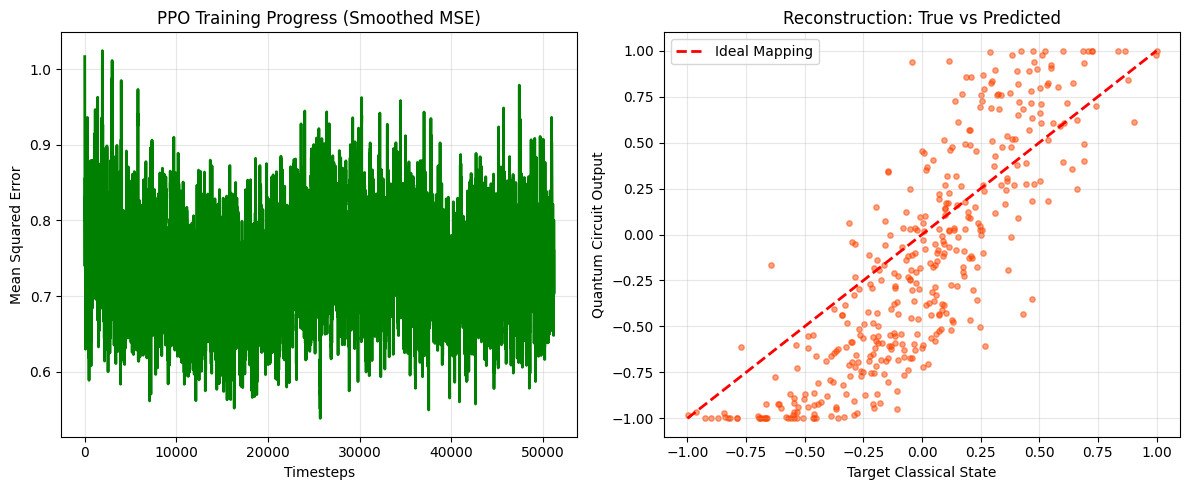

In [29]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np


# Helper: Smooth noisy RL metrics

def exponential_smooth(data, alpha=0.95):
    smoothed = []
    last = data[0]
    for point in data:
        smoothed_val = alpha * last + (1 - alpha) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

smoothed_mse = exponential_smooth(tracker.error_log)


# Evaluation on test batch

test_env = QuantumStateEnv()
targets_list = []
predictions_list = []

obs, _ = test_env.reset()
for _ in range(100):

    # deterministic action from trained PPO
    action, _ = agent.predict(obs, deterministic=True)
    obs, reward, done, _, info = test_env.step(action)

    targets_list.extend(info["target"])
    predictions_list.extend(info["prediction"])


# Plotting

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#  Smoothed MSE curve
ax1.plot(smoothed_mse, color='green', lw=2)
ax1.set_title("PPO Training Progress (Smoothed MSE)")
ax1.set_xlabel("Timesteps")
ax1.set_ylabel("Mean Squared Error")
ax1.grid(alpha=0.3)

# Target vs Quantum Output
ax2.scatter(targets_list, predictions_list, color='orangered', alpha=0.5, s=15)
ax2.plot([-1, 1], [-1, 1], 'r--', lw=2, label="Ideal Mapping")
ax2.set_title("Reconstruction: True vs Predicted")
ax2.set_xlabel("Target Classical State")
ax2.set_ylabel("Quantum Circuit Output")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()